# Customer Analytics: Predicting Term Deposit Subscription

## Goal
Predict whether a bank client will subscribe to a term deposit based on demographic, financial, and campaign data.

## Business Impact
Improves marketing efficiency by identifying high-probability customers, increasing conversion rates while reducing campaign costs.

## Approach
- Built classification models to estimate subscription probability
- Analyzed feature importance to identify key drivers of customer response
- Segmented customers based on predicted likelihood of conversion
- Simulated targeting strategies for campaign optimization

## Evaluation
- ROC-AUC and classification metrics
- Lift analysis and conversion rate comparison across segments

## Key Insight
Targeting high-probability customers significantly improves campaign ROI compared to mass marketing strategies.

### Ignore warnings

In [58]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### Importing libraries

In [59]:
import pandas as pd
import numpy as np

### Load the dataset

In [60]:
df = pd.read_csv('bank-full.csv', sep=';')

In [61]:
df.shape

(45211, 17)

In [62]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Data structure diagnosis

In [63]:
def simple_inspect(df):
    summary = []  # store results for each column

    for col in df.columns:
        s = df[col]  # current column
        nonnull = s.dropna()  # remove missing values

        # sample up to 10 unique values (for quick inspection)
        sample_vals = [str(x)[:30] for x in nonnull.unique()[:10]]

        # % of missing values
        missing_pct = round(s.isna().mean() * 100, 2)

        # number of unique values (excluding NaN)
        unique_vals = s.nunique(dropna=True)

        # initialize stats
        min_val = None
        max_val = None
        skewness = None

        # compute stats only for numeric columns
        if pd.api.types.is_numeric_dtype(s) and len(nonnull) > 0:
            min_val = nonnull.min()
            max_val = nonnull.max()

            # skewness requires at least 3 values
            if len(nonnull) > 2:
                skewness = round(nonnull.skew(), 3)

        # store results
        summary.append({
            "Column": col,
            "Sample Values": sample_vals,
            "Dtype": str(s.dtype),
            "Missing %": missing_pct,
            "Unique": unique_vals,
            "Min": min_val,
            "Max": max_val,
            "Skewness": skewness
        })

    # return as DataFrame for easy viewing
    return pd.DataFrame(summary)


# run inspection
inspect_df = simple_inspect(df)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,age,"[58, 44, 33, 47, 35, 28, 42, 43, 41, 29]",int64,0.0,77,18.0,95.0,0.685
1,job,"[management, technician, entrepreneur, blue-co...",object,0.0,12,NaN,NaN,NaN
2,marital,"[married, single, divorced]",object,0.0,3,NaN,NaN,NaN
3,education,"[tertiary, secondary, unknown, primary]",object,0.0,4,NaN,NaN,NaN
4,default,"[no, yes]",object,0.0,2,NaN,NaN,NaN
5,balance,"[2143, 29, 2, 1506, 1, 231, 447, 121, 593, 270]",int64,0.0,7168,-8019.0,102127.0,8.360
6,housing,"[yes, no]",object,0.0,2,NaN,NaN,NaN
7,loan,"[no, yes]",object,0.0,2,NaN,NaN,NaN
8,contact,"[unknown, cellular, telephone]",object,0.0,3,NaN,NaN,NaN
9,day,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16]",int64,0.0,31,1.0,31.0,0.093


### Data dictionary

| Feature         | Meaning                                        | Type        | How to interpret                                            |
| --------------- | ---------------------------------------------- | ----------- | ----------------------------------------------------------- |
| **age**         | Customer age                                   | Numeric     | Younger/older segments may respond differently              |
| **job**         | Type of occupation                             | Categorical | Proxy for income stability / socioeconomic status           |
| **marital**     | Marital status                                 | Categorical | Affects financial responsibility and decision-making        |
| **education**   | Education level                                | Categorical | Proxy for financial literacy / income potential             |
| **default**     | Has credit in default                          | Binary      | Yes = higher financial risk                                 |
| **balance**     | Account balance                                | Continuous  | Higher balance = stronger financial position                |
| **housing**     | Has housing loan                               | Binary      | Indicates long-term financial obligation                    |
| **loan**        | Has personal loan                              | Binary      | Additional financial burden                                 |
| **contact**     | Contact communication type                     | Categorical | Operational variable (less predictive usually)              |
| **day + month** | Last contact date                              | Temporal    | Captures seasonal or timing effects                         |
| **duration**    | Call duration (seconds)                        | Continuous  | Strong predictor; longer = higher conversion (leakage risk) |
| **campaign**    | Number of contacts in current campaign         | Count       | Too many contacts = lower success probability               |
| **pdays**       | Days since last contact (-1 = never contacted) | Numeric     | Recent contact = higher conversion chance                   |
| **previous**    | Number of contacts before this campaign        | Count       | Indicates prior engagement level                            |
| **poutcome**    | Outcome of previous campaign                   | Categorical | Strong signal (success = high likelihood of response)       |
| **y**           | Target: subscribed to term deposit             | Binary      | yes = subscribed, no = not subscribed                       |


### Feature type groupings

In [64]:
datetime_cols = [
]

categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

ordinal_cols = [
]

numerical_cols = [
    'age',
    'day',
    'campaign',
    'previous'
]

skewed_cols = [
    'balance',
    'pdays'
]

missing_numerical_cols = [
]

missing_categorical_cols = [
]

drop_cols = [
    'duration'
]

target_col = 'y'

### Map target column

In [65]:
df[target_col] = df[target_col].map({"no": 0, "yes": 1})

### Feature type conversion

In [66]:
# drop unnecessary columns
df = df.drop(columns=drop_cols, errors="ignore")

# convert categorical columns to category dtype
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# convert ordinal + numerical + skewed columns to numeric
# errors="coerce" → invalid values become NaN
for col in ordinal_cols + numerical_cols + skewed_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# convert datetime columns to datetime format
# errors="coerce" → invalid dates become NaN
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# check final data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  campaign   45211 non-null  int64   
 12  pdays      45211 non-null  int64   
 13  previous   45211 non-null  int64   
 14  poutcome   45211 non-null  category
 15  y          45211 non-null  int64   
dtypes: category(9), int64(7)
memory usage: 2.8 MB


### Removing duplicates

In [67]:
before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print("Removed rows:", before - after)

Removed rows: 16


### Exploratory data analysis

In [68]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

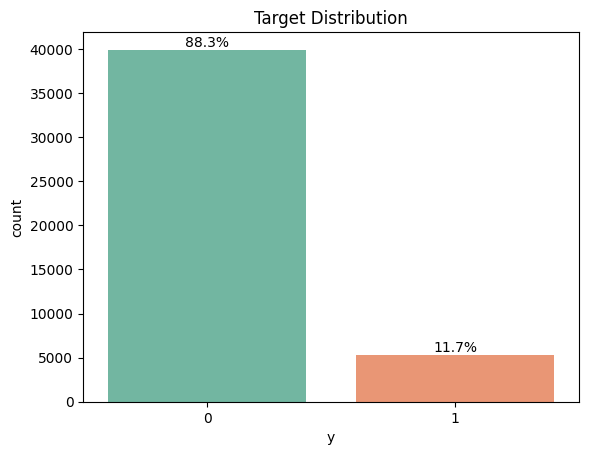

In [69]:
plt.figure()
ax = sns.countplot(x=target_col, data=df, palette="Set2")

# total count for percentage
total = len(df)

# add labels
for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total
    ax.annotate(f'{percent:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Target Distribution")
plt.show()

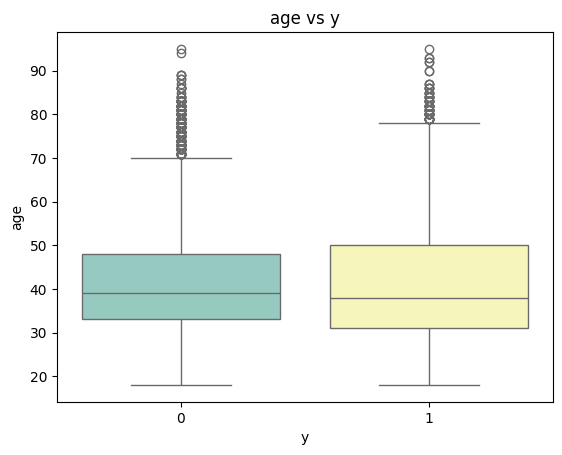

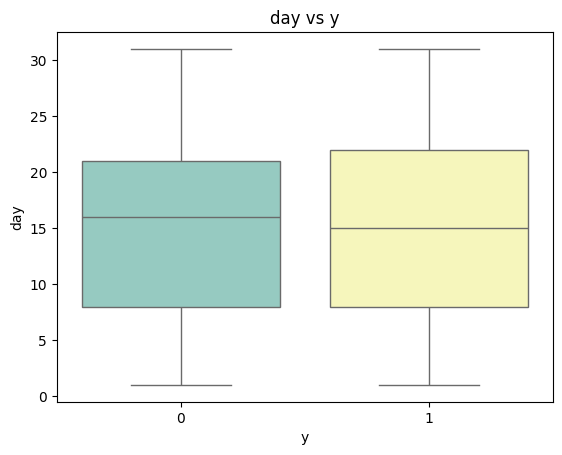

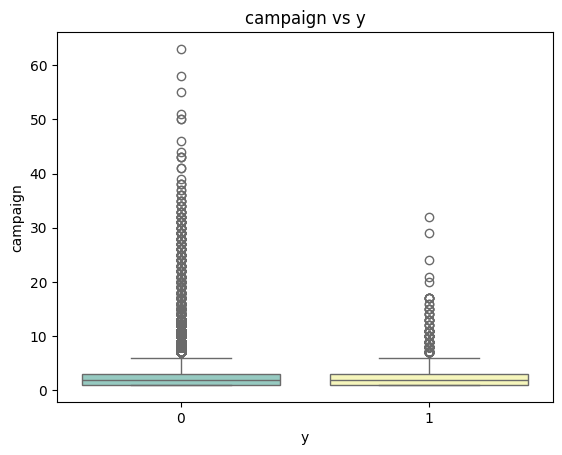

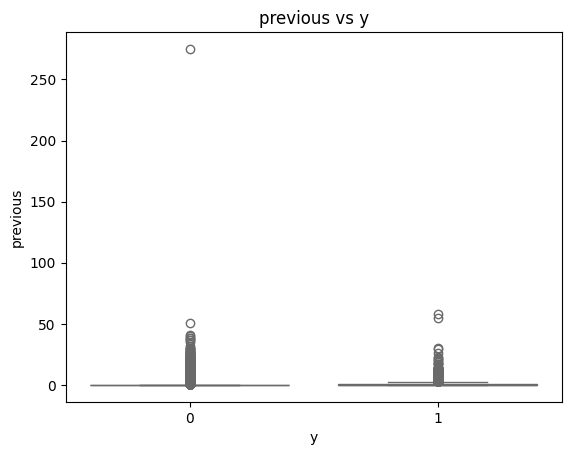

In [70]:
# loop through each numerical feature
for col in numerical_cols:
    
    plt.figure()  # create a new plot for each feature
    
    # boxplot: compare distribution of feature across target classes (0 vs 1)
    sns.boxplot(x=target_col, y=col, data=df, palette="Set3")
    
    # set plot title
    plt.title(f"{col} vs {target_col}")
    
    plt.show()  # display the plot


=== job vs y ===


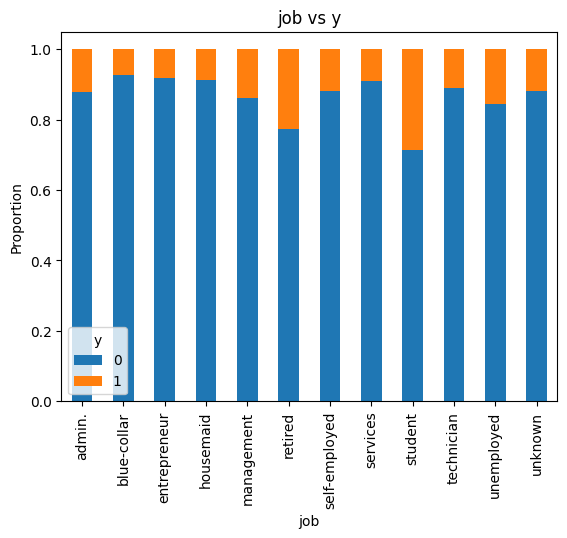


=== marital vs y ===


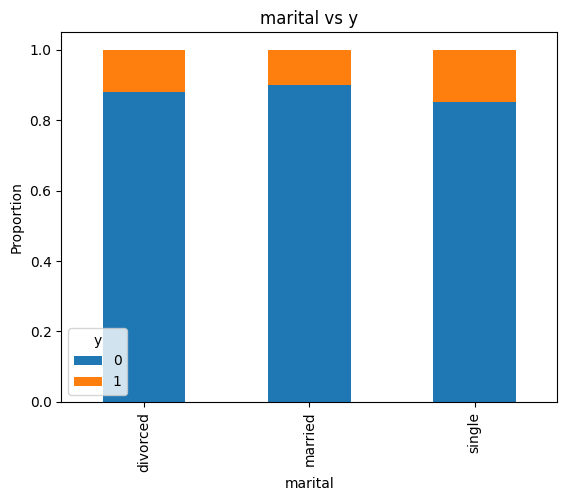


=== education vs y ===


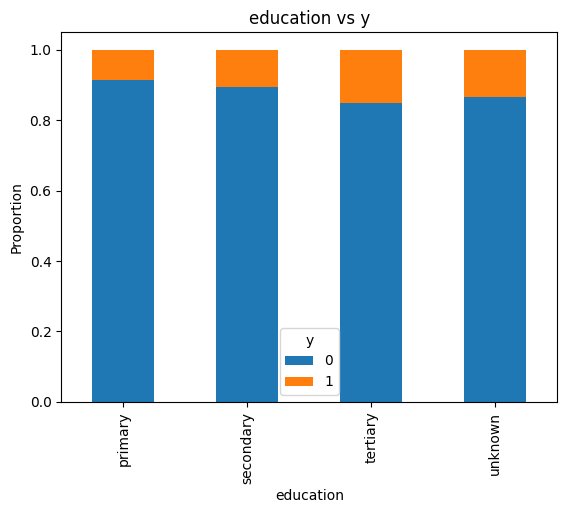


=== default vs y ===


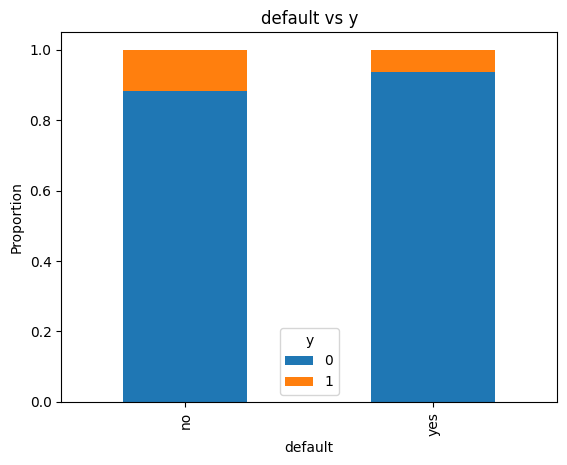


=== housing vs y ===


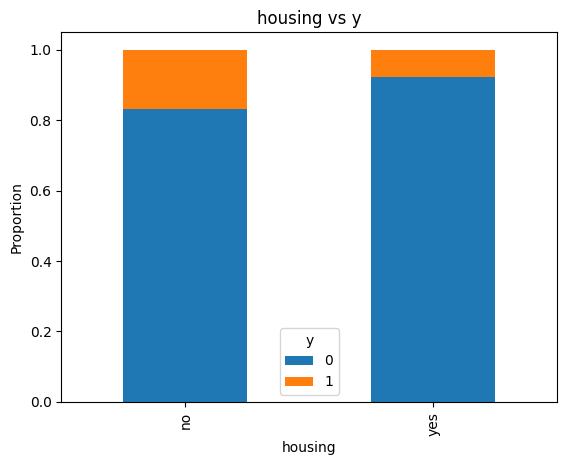


=== loan vs y ===


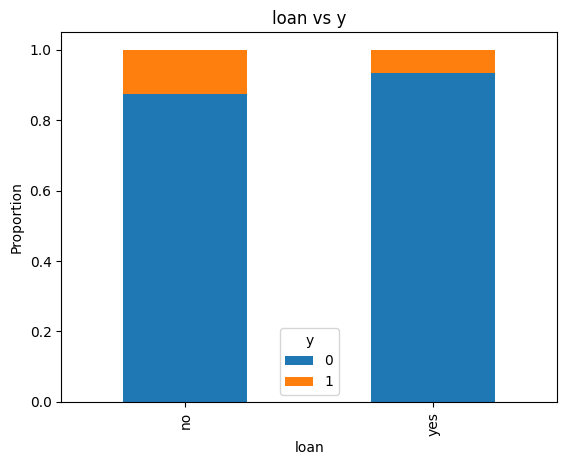


=== contact vs y ===


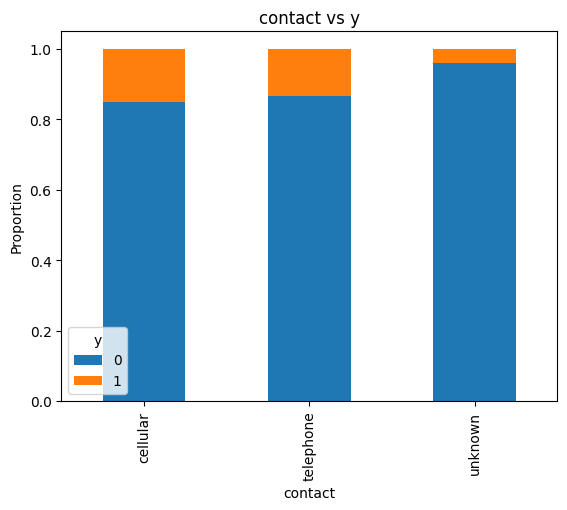


=== month vs y ===


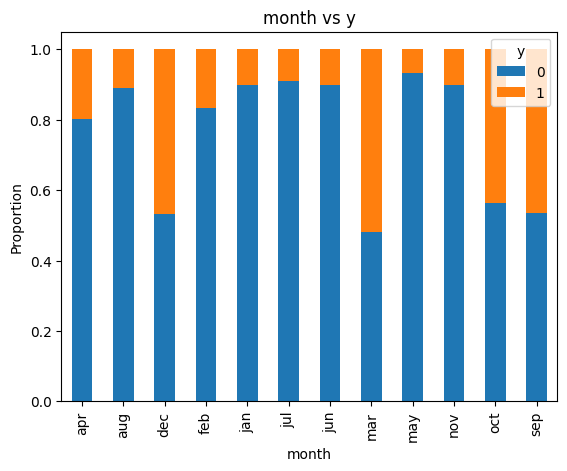


=== poutcome vs y ===


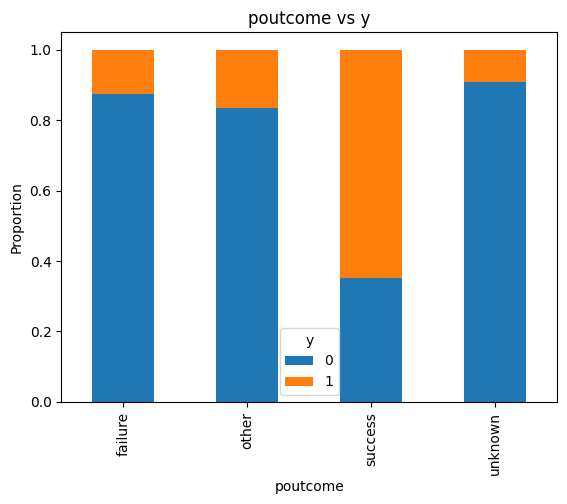

In [71]:
# loop through categorical and ordinal features
for col in categorical_cols + ordinal_cols:
    
    # print section header for readability
    print(f"\n=== {col} vs {target_col} ===")
    
    # create cross-tab:
    # rows = categories, columns = target (0/1)
    # normalize="index" → proportions per category (row-wise)
    ct = pd.crosstab(df[col], df[target_col], normalize="index")
    
    # plot stacked bar chart (shows distribution of target within each category)
    ct.plot(kind="bar", stacked=True)
    
    # set title and label
    plt.title(f"{col} vs {target_col}")
    plt.ylabel("Proportion")
    
    plt.show()  # display plot

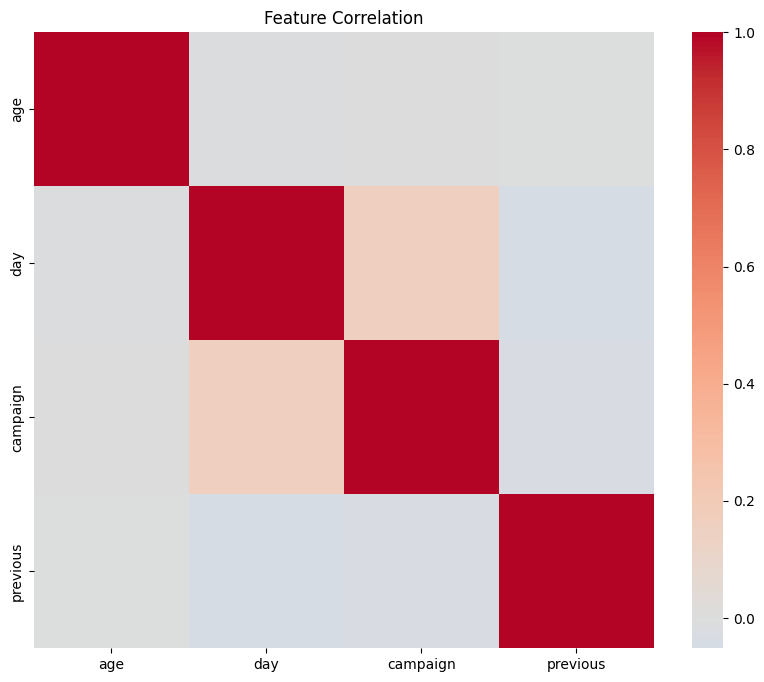

In [72]:
# compute correlation matrix for numerical features
corr = df[numerical_cols].corr()

# create figure with size
plt.figure(figsize=(10,8))

# heatmap:
# cmap="coolwarm" → blue (negative), red (positive)
# center=0 → center color at zero correlation
sns.heatmap(corr, cmap="coolwarm", center=0)

# title of the plot
plt.title("Feature Correlation")

# display the heatmap
plt.show()

### Feature Engineering

### Converted data structure diagnosis

In [73]:
inspect_df = simple_inspect(df)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,age,"[58, 44, 33, 47, 35, 28, 42, 43, 41, 29]",int64,0.0,77,18.0,95.0,0.685
1,job,"[management, technician, entrepreneur, blue-co...",category,0.0,12,NaN,NaN,NaN
2,marital,"[married, single, divorced]",category,0.0,3,NaN,NaN,NaN
3,education,"[tertiary, secondary, unknown, primary]",category,0.0,4,NaN,NaN,NaN
4,default,"[no, yes]",category,0.0,2,NaN,NaN,NaN
5,balance,"[2143, 29, 2, 1506, 1, 231, 447, 121, 593, 270]",int64,0.0,7168,-8019.0,102127.0,8.359
6,housing,"[yes, no]",category,0.0,2,NaN,NaN,NaN
7,loan,"[no, yes]",category,0.0,2,NaN,NaN,NaN
8,contact,"[unknown, cellular, telephone]",category,0.0,3,NaN,NaN,NaN
9,day,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16]",int64,0.0,31,1.0,31.0,0.093


### Separate X and y variable

In [74]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [75]:
print(X.shape)
print(y.shape)
print(y.value_counts(normalize=True))

(45195, 15)
(45195,)
y
0    0.882974
1    0.117026
Name: proportion, dtype: float64


### Train-Validation-Test split

In [76]:
from sklearn.model_selection import train_test_split

# first split:
# 70% train, 30% temporary (to be split into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,          # 30% goes to temp
    random_state=42,        # ensures reproducibility
    stratify=y              # keeps class distribution consistent
)

# second split:
# split the 30% temp into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,          # split temp equally → 15% val, 15% test
    random_state=42,
    stratify=y_temp         # maintain class balance
)

X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

In [77]:
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Train: y
0    0.882981
1    0.117019
Name: proportion, dtype: float64
Val: y
0    0.883021
1    0.116979
Name: proportion, dtype: float64
Test: y
0    0.882891
1    0.117109
Name: proportion, dtype: float64


### Handling Missing Values

In [78]:
# 1. Create missing flags (before imputation)
# mark where values were originally missing (useful signal for model)
for col in missing_numerical_cols:
    X_train[f"{col}_missing"] = X_train[col].isna().astype(int)
    X_val[f"{col}_missing"] = X_val[col].isna().astype(int)
    X_test[f"{col}_missing"] = X_test[col].isna().astype(int)

# 2. Compute medians (train only)
# use only training data to avoid data leakage
medians = X_train[missing_numerical_cols].median()

# 3. Impute missing values (apply same medians to all splits)
X_train[missing_numerical_cols] = X_train[missing_numerical_cols].fillna(medians)
X_val[missing_numerical_cols] = X_val[missing_numerical_cols].fillna(medians)
X_test[missing_numerical_cols] = X_test[missing_numerical_cols].fillna(medians)

In [79]:
print(X_train[missing_numerical_cols].isna().sum())
print(X_val[missing_numerical_cols].isna().sum())
print(X_test[missing_numerical_cols].isna().sum())

Series([], dtype: float64)
Series([], dtype: float64)
Series([], dtype: float64)


### Log transform skewed data

In [80]:
log_cols = []  # store names of new log-transformed columns

for col in skewed_cols:
    new_col = f"{col}_log"
    
    # apply log transform (log1p handles zeros safely)
    # clip(lower=0) → avoids issues if negative values exist
    X_train[new_col] = np.log1p(X_train[col].clip(lower=0))
    X_val[new_col]   = np.log1p(X_val[col].clip(lower=0))
    X_test[new_col]  = np.log1p(X_test[col].clip(lower=0))
    
    # save new column name
    log_cols.append(new_col)

# drop original skewed columns (only keep log versions)
X_train = X_train.drop(columns=skewed_cols)
X_val   = X_val.drop(columns=skewed_cols)
X_test  = X_test.drop(columns=skewed_cols)

# check distribution of transformed features
display(X_train[log_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
balance_log,31636.0,5.320499,2.783513,0.0,4.317488,6.109248,7.261225,11.496979
pdays_log,31636.0,0.951684,2.043086,0.0,0.000000,0.000000,0.000000,6.770789


### Encoding categorical features

In [81]:
# one-hot encode categorical variables
# drop_first=True → removes one category per feature (for LR to avoid multicollinearity)
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True, dtype=int)
X_val   = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True, dtype=int)

# align validation and test columns to match training set
# ensures same feature space (important for model input)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

display(X_train.head())

,age,day,campaign,previous,balance_log,pdays_log,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
38473,38,15,7,0,7.635304,0.000000,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
40578,61,21,6,0,3.931826,0.000000,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
23451,30,28,8,0,6.309918,0.000000,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
37021,28,13,1,0,0.000000,0.000000,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
38836,34,18,1,2,6.142037,5.703782,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0


### Scaling numerical features

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # initialize scaler

# scale numerical + log features
# fit ONLY on training data (to avoid data leakage)
X_train[numerical_cols + log_cols] = scaler.fit_transform(
    X_train[numerical_cols + log_cols]
)

# apply same scaling to validation and test sets
X_val[numerical_cols + log_cols] = scaler.transform(
    X_val[numerical_cols + log_cols]
)
X_test[numerical_cols + log_cols] = scaler.transform(
    X_test[numerical_cols + log_cols]
)

display(X_train.head())

,age,day,campaign,previous,balance_log,pdays_log,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
38473,-0.273718,-0.097778,1.387752,-0.236114,0.831626,-0.465814,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
40578,1.894889,0.622014,1.061021,-0.236114,-0.498900,-0.465814,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
23451,-1.028016,1.461770,1.714484,-0.236114,0.355463,-0.465814,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
37021,-1.216591,-0.337709,-0.572638,-0.236114,-1.911463,-0.465814,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
38836,-0.650867,0.262118,-0.572638,0.578823,0.295149,2.325978,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0


### Final inspection of training set

In [83]:
inspect_df = simple_inspect(X_train)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,age,"[-0.27371804429973995, 1.8948894593776442, -1....",float64,0.0,76,-2.159464,5.100657,0.691
1,day,"[-0.09777798516754452, 0.622013600349719, 1.46...",float64,0.0,31,-1.777292,1.821666,0.091
2,campaign,"[1.3877523623371697, 1.0610206980155301, 1.714...",float64,0.0,44,-0.572638,19.684726,4.797
3,previous,"[-0.23611431253612206, 0.578822671032802, 0.17...",float64,0.0,39,-0.236114,111.817721,48.052
4,balance_log,"[0.8316260353391428, -0.49890021468029394, 0.3...",float64,0.0,5460,-1.911463,2.218987,-0.866
5,pdays_log,"[-0.4658143821287379, 2.325978268987541, 2.415...",float64,0.0,509,-0.465814,2.848239,1.719
6,job_blue-collar,"[0, 1]",int64,0.0,2,0.000000,1.000000,1.369
7,job_entrepreneur,"[1, 0]",int64,0.0,2,0.000000,1.000000,5.259
8,job_housemaid,"[0, 1]",int64,0.0,2,0.000000,1.000000,5.663
9,job_management,"[0, 1]",int64,0.0,2,0.000000,1.000000,1.438


### Model selection

In [84]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier

# class imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# base models
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# parameter grids
lr_param_grid = {
    "C": [0.1, 1, 10]
}

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

# grid searches
models = {
    "Logistic Regression": GridSearchCV(
        estimator=lr,
        param_grid=lr_param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    ),
    "XGBoost": GridSearchCV(
        estimator=xgb,
        param_grid=xgb_param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )
}

# threshold candidates
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

best_model = None
best_model_name = None
best_threshold = None
best_score = -1

# train and validate each model
for name, search in models.items():
    start = time.time()

    # fit on training set
    search.fit(X_train, y_train)
    model = search.best_estimator_

    # predict probabilities on validation set
    y_val_proba = model.predict_proba(X_val)[:, 1]

    # find best threshold using F1 on validation set
    best_t = 0.5
    best_f1 = 0

    for t in thresholds:
        y_pred = (y_val_proba >= t).astype(int)
        f1 = f1_score(y_val, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    # final validation predictions using best threshold
    y_pred_final = (y_val_proba >= best_t).astype(int)

    precision = precision_score(y_val, y_pred_final, zero_division=0)
    recall = recall_score(y_val, y_pred_final, zero_division=0)
    f1_final = f1_score(y_val, y_pred_final, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_val_proba)
    pr_auc = average_precision_score(y_val, y_val_proba)
    runtime = time.time() - start

    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Best Threshold": round(best_t, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1_final,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Runtime (s)": runtime
    })

    print(f"\n{name}")
    print("Best Params:", search.best_params_)
    print("Best Threshold:", round(best_t, 2))
    print("F1:", round(f1_final, 4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("PR-AUC:", round(pr_auc, 4))

    # keep best model based on ROC-AUC
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = model
        best_model_name = name
        best_threshold = best_t

# results table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

print("\nModel Comparison:")
display(results_df)

print("\nFINAL CHOICE")
print("Best Model     :", best_model_name)
print("Best Threshold :", round(best_threshold, 2))
print("Best ROC-AUC   :", round(best_score, 4))


Logistic Regression
Best Params: {'C': 0.1}
Best Threshold: 0.65
F1: 0.4397
ROC-AUC: 0.7717
PR-AUC: 0.4118

XGBoost
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Threshold: 0.65
F1: 0.4778
ROC-AUC: 0.7946
PR-AUC: 0.4517

Model Comparison:


,Model,Best Params,Best Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,Runtime (s)
1,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.65,0.466907,0.489281,0.477833,0.794587,0.451715,3.295529
0,Logistic Regression,{'C': 0.1},0.65,0.449868,0.430013,0.439716,0.771709,0.411826,2.429857



FINAL CHOICE
Best Model     : XGBoost
Best Threshold : 0.65
Best ROC-AUC   : 0.7946


### Run final evaluation on the test set

In [85]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# 1. Lock final model and threshold
final_model = best_model
final_threshold = best_threshold

print("Locked Final Model     :", best_model_name)
print("Locked Final Threshold :", round(final_threshold, 2))
print("Locked Best Params     :", final_model.get_params())

# 2. Use test set
# same processed test data for both models
X_test_final = X_test

# 3. Predict on TEST set
# predicted probabilities for positive class
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

# convert probabilities to class predictions using locked threshold
y_test_pred = (y_test_proba >= final_threshold).astype(int)

# 4. Compute test metrics
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("\nFINAL TEST RESULTS")
print("Test Precision :", round(test_precision, 4))
print("Test Recall    :", round(test_recall, 4))
print("Test F1 Score  :", round(test_f1, 4))
print("Test ROC-AUC   :", round(test_roc_auc, 4))
print("Test PR-AUC    :", round(test_pr_auc, 4))

# show target distribution for context
print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index())

# 5. Detailed classification results
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

# labeled confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

print("\nTest Confusion Matrix:")
display(cm_df)

# 6. Save final metrics in a table
final_test_results = pd.DataFrame([{
    "Model": best_model_name,
    "Threshold": round(final_threshold, 2),
    "Precision": test_precision,
    "Recall": test_recall,
    "F1 Score": test_f1,
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc
}])

display(final_test_results)

Locked Final Model     : XGBoost
Locked Final Threshold : 0.65
Locked Best Params     : {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': np.float64(7.545650999459752), 'subsample': None, 'tree_method': None, 'validate_pa

,Pred 0,Pred 1
Actual 0,5548,438
Actual 1,391,403


,Model,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.65,0.479191,0.507557,0.492966,0.79808,0.426019


### SHAP for interpretability

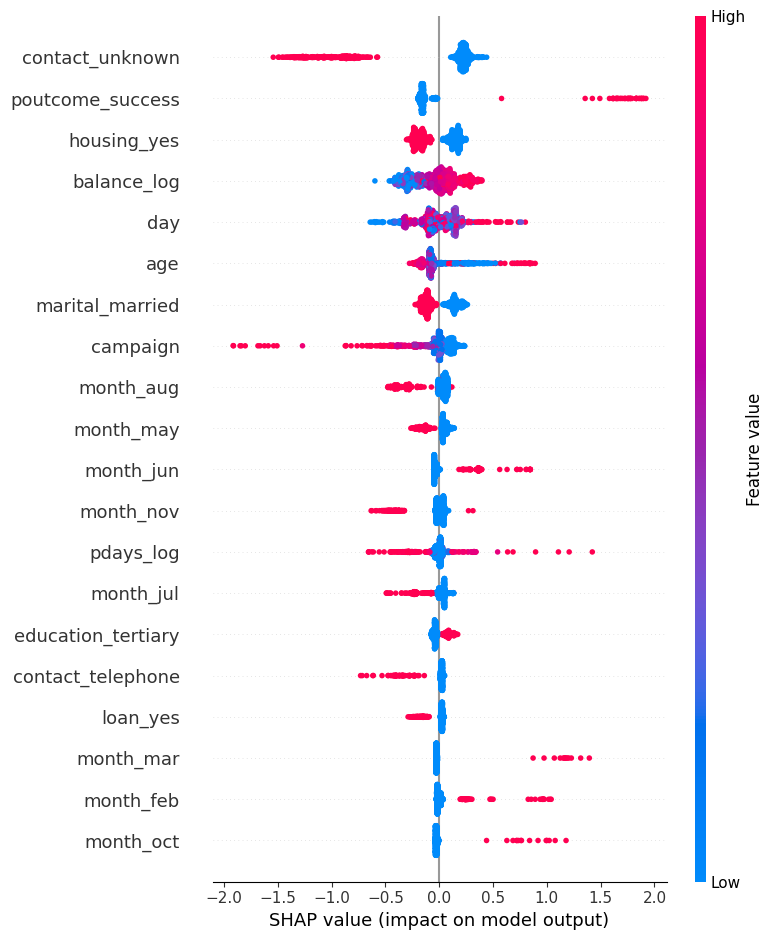

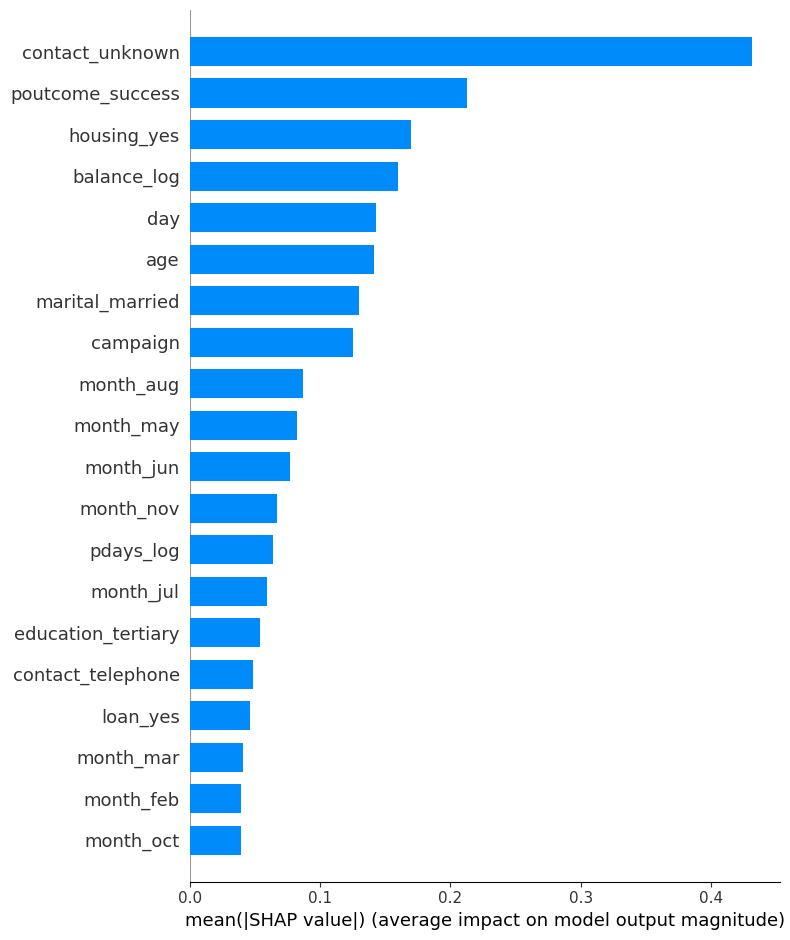

In [86]:
import shap

# sample test set for speed
X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)

if best_model_name == "XGBoost":
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

elif best_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(
        best_model,
        X_train,
        feature_perturbation="interventional"
    )
    shap_values = explainer.shap_values(X_shap)

# summary plot
shap.summary_plot(shap_values, X_shap)

# bar plot
shap.summary_plot(shap_values, X_shap, plot_type="bar")